# Constraint Comparison for `jax_check142`
对比三种策略：
1. 硬边界惩罚（`hard_bounds`）
2. 第一版可微约束（无 latent 缩放）
3. 可跑通版本：`latent` 缩放 + 可微约束


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')

## 1) 定义三种约束映射
- 为了直观，我们把 `x` 当作 `gamma_lat/delta_lat` 的一维切片。
- 硬边界版本里，参数直接由 latent 给出，再加不可微硬惩罚。


In [2]:
# latent grid
x = np.linspace(-10, 10, 4001)

def sigmoid(t):
    return 1.0 / (1.0 + np.exp(-t))

# ---- hard-bound version (conceptual) ----
gamma_hard = x.copy()
delta_hard = x.copy()
logpen_gamma_hard = np.where((gamma_hard > 1.01) & (gamma_hard < 2.99), 0.0, -1e20)
logpen_delta_hard = np.where((delta_hard > 0.51) & (delta_hard < 2.99), 0.0, -1e20)

# ---- first differentiable version ----
gamma_diff1 = 1.01 + (2.99 - 1.01) * sigmoid(x)
delta_diff1 = 0.51 + (2.99 - 0.51) * sigmoid(x)

# ---- final working version in jax_check142 ----
gamma_diff2 = 1.01 + (2.99 - 1.01) * sigmoid(0.3 * x)
delta_diff2 = 0.51 + (2.80 - 0.51) * sigmoid(0.3 * x)


## 2) 硬边界惩罚 vs 可微约束


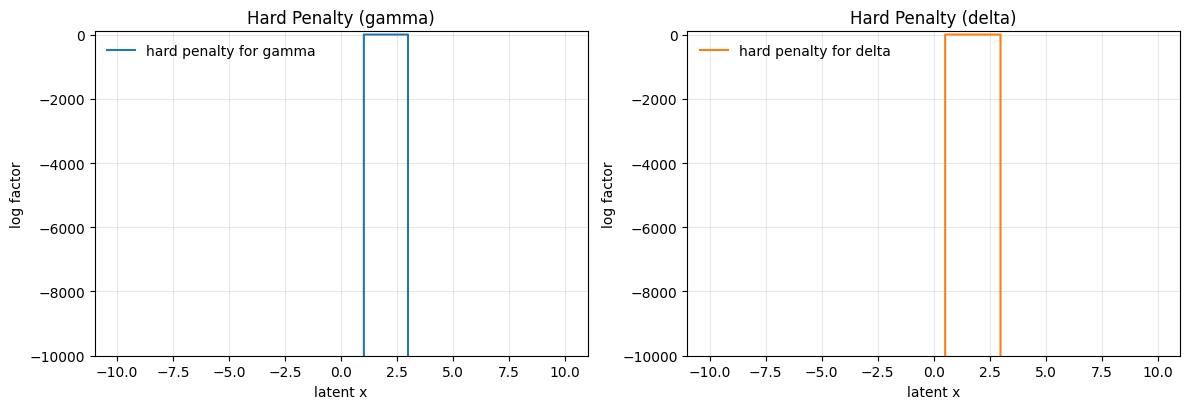

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

ax[0].plot(x, logpen_gamma_hard, lw=1.5, label='hard penalty for gamma')
ax[0].set_title('Hard Penalty (gamma)')
ax[0].set_xlabel('latent x')
ax[0].set_ylabel('log factor')
ax[0].set_ylim(-1e4, 100)
ax[0].grid(alpha=0.3)

ax[1].plot(x, logpen_delta_hard, lw=1.5, color='tab:orange', label='hard penalty for delta')
ax[1].set_title('Hard Penalty (delta)')
ax[1].set_xlabel('latent x')
ax[1].set_ylabel('log factor')
ax[1].set_ylim(-1e4, 100)
ax[1].grid(alpha=0.3)

for a in ax:
    a.legend(frameon=False)

plt.tight_layout()
plt.show()


## 3) `gamma/delta` 映射曲线对比
- 第一版可微约束会把 `delta` 上界推到 `2.99`，非常接近奇点 `d=3`。
- 最终版把 `delta` 上界收紧到 `2.80`，并加了 `0.3` 缩放，避免大量样本贴边。


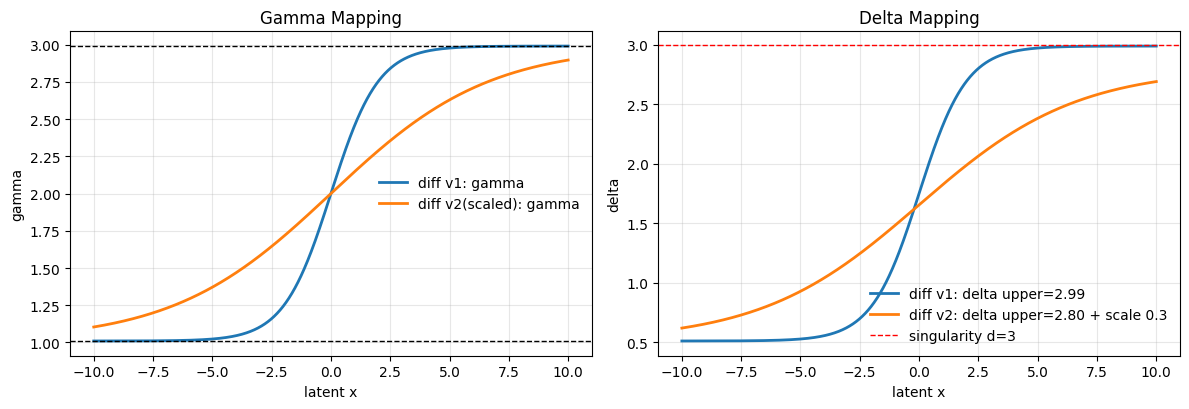

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# gamma
ax[0].plot(x, gamma_diff1, lw=2, label='diff v1: gamma')
ax[0].plot(x, gamma_diff2, lw=2, label='diff v2(scaled): gamma')
ax[0].axhline(1.01, ls='--', c='k', lw=1)
ax[0].axhline(2.99, ls='--', c='k', lw=1)
ax[0].set_title('Gamma Mapping')
ax[0].set_xlabel('latent x')
ax[0].set_ylabel('gamma')
ax[0].grid(alpha=0.3)
ax[0].legend(frameon=False)

# delta
ax[1].plot(x, delta_diff1, lw=2, label='diff v1: delta upper=2.99')
ax[1].plot(x, delta_diff2, lw=2, label='diff v2: delta upper=2.80 + scale 0.3')
ax[1].axhline(3.0, ls='--', c='red', lw=1, label='singularity d=3')
ax[1].set_title('Delta Mapping')
ax[1].set_xlabel('latent x')
ax[1].set_ylabel('delta')
ax[1].grid(alpha=0.3)
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 4) 奇点风险指标对比：`|1/(d-3)|`
`f_prime_jax` 里有 `(d-3)` 分母，`d` 接近 3 时数值会急剧恶化。


In [ ]:
eps = 1e-12
risk1 = np.abs(1.0 / np.maximum(np.abs(delta_diff1 - 3.0), eps))
risk2 = np.abs(1.0 / np.maximum(np.abs(delta_diff2 - 3.0), eps))

# 可视化时截断，避免无限大把图压扁
risk_cap = 200
r1 = np.clip(risk1, 0, risk_cap)
r2 = np.clip(risk2, 0, risk_cap)

fig, ax = plt.subplots(1, 1, figsize=(8.5, 4.2))
ax.plot(x, r1, lw=2, label='diff v1 risk')
ax.plot(x, r2, lw=2, label='diff v2 risk (scaled + tighter upper bound)')
ax.set_xlabel('latent x')
ax.set_ylabel('|1/(delta-3)| (clipped)')
ax.set_title('Singularity Risk Comparison')
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('risk v1 max (raw):', float(np.max(risk1)))
print('risk v2 max (raw):', float(np.max(risk2)))


## 5) 局部敏感度（导数）对比
- `latent` 缩放 `0.3` 会把斜率整体压低到约 30%，梯度更温和。


In [ ]:
# analytical derivative of a + (b-a)*sigmoid(kx)
def dmap(x, a, b, k):
    s = sigmoid(k * x)
    return (b - a) * k * s * (1 - s)

dg1 = dmap(x, 1.01, 2.99, 1.0)
dg2 = dmap(x, 1.01, 2.99, 0.3)
dd1 = dmap(x, 0.51, 2.99, 1.0)
dd2 = dmap(x, 0.51, 2.80, 0.3)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(x, dg1, lw=2, label='gamma diff v1')
ax[0].plot(x, dg2, lw=2, label='gamma diff v2')
ax[0].set_title('d gamma / d latent')
ax[0].set_xlabel('latent x')
ax[0].grid(alpha=0.3)
ax[0].legend(frameon=False)

ax[1].plot(x, dd1, lw=2, label='delta diff v1')
ax[1].plot(x, dd2, lw=2, label='delta diff v2')
ax[1].set_title('d delta / d latent')
ax[1].set_xlabel('latent x')
ax[1].grid(alpha=0.3)
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print('max |d gamma/dx| v1:', float(np.max(dg1)), ' v2:', float(np.max(dg2)))
print('max |d delta/dx| v1:', float(np.max(dd1)), ' v2:', float(np.max(dd2)))


## 结论（为何最后一版更容易跑通）
1. **去掉硬边界 cliff**：从 `-1e20` 的不可微硬截断，变成平滑映射，HMC/NUTS 更容易找到可行轨迹。  
2. **远离 `delta=3` 奇点**：`delta` 上界从 `2.99` 收紧到 `2.80`，显著降低 `1/(d-3)` 爆炸风险。  
3. **latent 缩放降低敏感度**：`0.3` 缩放降低局部梯度，减少 leapfrog 数值不稳定与初始化失败概率。  

这三点叠加，使“初始化可行域”更大、几何更平滑，因此最后一版更容易跑通。


## 6) Gaussian latent -> sigmoid 之后的 $\gamma_i$ 概率密度
设 $X=\gamma_{lat}\sim\mathcal{N}(\mu,\sigma^2)$，并定义
$\gamma = a + (b-a)\,\sigma_g(kX),\quad \sigma_g(t)=\frac{1}{1+e^{-t}}.$
则（对 $\gamma\in(a,b)$）
$f_\gamma(\gamma)=f_X(x(\gamma))\left|\frac{dx}{d\gamma}\right|,
x(\gamma)=\frac{1}{k}\operatorname{logit}\!\left(\frac{\gamma-a}{b-a}\right),
\frac{dx}{d\gamma}=\frac{1}{k(b-a)s(1-s)},\ s=\frac{\gamma-a}{b-a}.$
这就是 logistic-normal（区间缩放版）诱导密度。


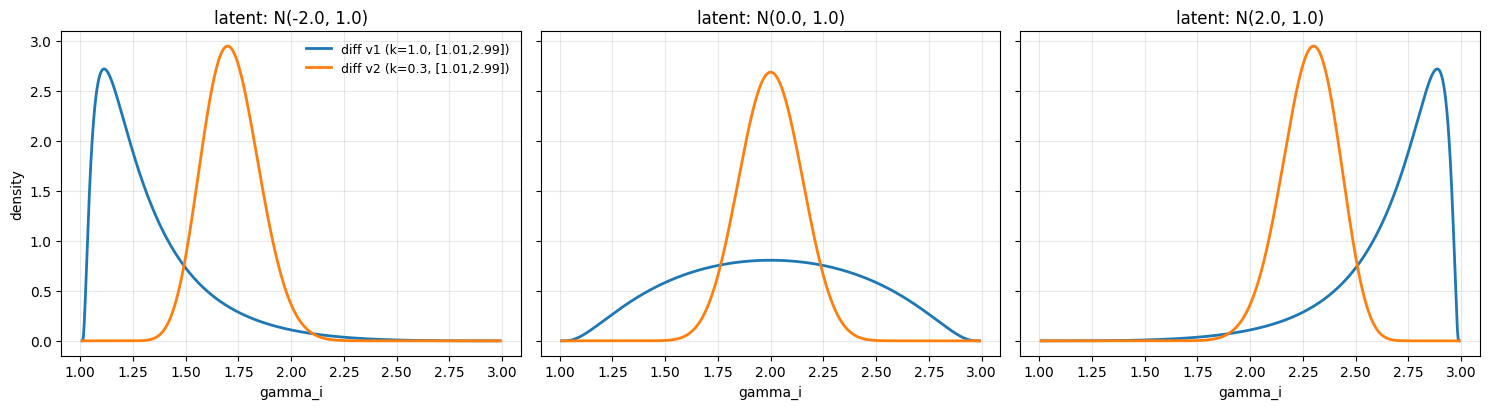

Interpretation: k=0.3 generally gives a flatter, less extreme transformed density and weaker local sensitivity.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def normal_pdf(x, mu, sigma):
    z = (x - mu) / sigma
    return np.exp(-0.5 * z * z) / (np.sqrt(2.0 * np.pi) * sigma)

def transformed_pdf_gamma(y, mu, sigma, a, b, k):
    eps = 1e-12
    s = (y - a) / (b - a)
    s = np.clip(s, eps, 1.0 - eps)
    x = (1.0 / k) * np.log(s / (1.0 - s))
    jac = 1.0 / (k * (b - a) * s * (1.0 - s))
    pdf = normal_pdf(x, mu, sigma) * jac
    pdf[(y <= a) | (y >= b)] = 0.0
    return pdf

# 与当前 notebook 三种策略对应的 gamma 映射参数
cfg = [
    ('diff v1 (k=1.0, [1.01,2.99])', 1.01, 2.99, 1.0, 'tab:blue'),
    ('diff v2 (k=0.3, [1.01,2.99])', 1.01, 2.99, 0.3, 'tab:orange'),
]

# 假设 latent 在某点附近高斯
mu_sigma_list = [(-2.0, 1.0), (0.0, 1.0), (2.0, 1.0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (mu, sigma) in zip(axes, mu_sigma_list):
    for label, a, b, k, color in cfg:
        y = np.linspace(a + 1e-6, b - 1e-6, 1200)
        pdf = transformed_pdf_gamma(y, mu=mu, sigma=sigma, a=a, b=b, k=k)
        ax.plot(y, pdf, lw=2, color=color, label=label)
    ax.set_title(f'latent: N({mu}, {sigma**2:.1f})')
    ax.set_xlabel('gamma_i')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('density')
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print('Interpretation: k=0.3 generally gives a flatter, less extreme transformed density and weaker local sensitivity.')


## 7) 这种做法是否合理？有文献支持吗？
结论：**合理，而且是常见做法**。

- 对受限参数（区间约束）使用 logit/sigmoid 双射映射到无约束空间，是 HMC/NUTS 的标准技术路径。
- 这种变换会改变参数的诱导先验形状（不是区间均匀），需要结合 Jacobian 理解其概率密度。
- 在数值上，适当的 latent 缩放（如 `k=0.3`）可降低局部敏感度，缓解几何过硬导致的初始化/采样失败。

可参考：
- Stan Reference Manual: Constraint Transforms（区间参数 logit 变换与 Jacobian）
  https://mc-stan.org/docs/reference-manual/transforms.html
- Aitchison & Shen (1980), *Logistic-normal distributions: Some properties and uses*（logistic-normal 经典来源）
  https://doi.org/10.1093/biomet/67.2.261
